# Lab 01 : Deep Q-Learning (DQN) - demo


This notebook demonstrates Deep Q-Learning (DQN) applied to the CartPole-v0 environment. It illustrates how a neural network learns to balance a pole on a cart through reinforcement learning.

Core Architecture: Uses a 2-layer neural network (DQN) to predict action scores.

Stability Mechanisms: Implements Replay Memory to store experiences and a Baseline (Target) Network to stabilize the training process.

Training Loop: Features an epsilon-greedy exploration strategy and plots training progress as the model reaches its 400-step balancing goal.


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    !pip install 'gymnasium[classic_control]' 
    !pip install gym-notebook-wrapper
    

In [2]:
import torch
import torch.nn as nn
torch.manual_seed(torch.randint(10000,())) # random seed for pythorch random generator
import time
import numpy as np
import os
import pickle
import gymnasium as gym 
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from collections import namedtuple
import random
from itertools import count


# Dataset

In [3]:
#Initialize the environment with the same seed/initialization value
env = gym.make('CartPole-v1')

# Reset the environment
state, info = env.reset() # initial state from the environment
print('init state:',state)

# Rollout one episode until it finishes 
for t in count():  
    action = torch.LongTensor(1).random_(0,2).item() # randomly generated action=a in {0,1}
    state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
    done = terminated or truncated
    print('t=',t, 'action=',action, 'state=',np.array_str(state, precision=5), 'reward=',reward, 'done=',done )
    if done:
        break


init state: [-0.03700351 -0.02044246 -0.01870216 -0.03439369]
t= 0 action= 1 state= [-0.03741  0.17494 -0.01939 -0.33292] reward= 1.0 done= False
t= 1 action= 0 state= [-0.03391 -0.0199  -0.02605 -0.04641] reward= 1.0 done= False
t= 2 action= 1 state= [-0.03431  0.17559 -0.02698 -0.3472 ] reward= 1.0 done= False
t= 3 action= 1 state= [-0.0308   0.37108 -0.03392 -0.64826] reward= 1.0 done= False
t= 4 action= 0 state= [-0.02338  0.17645 -0.04689 -0.36645] reward= 1.0 done= False
t= 5 action= 0 state= [-0.01985 -0.01798 -0.05421 -0.08892] reward= 1.0 done= False
t= 6 action= 0 state= [-0.02021 -0.21228 -0.05599  0.18618] reward= 1.0 done= False
t= 7 action= 0 state= [-0.02445 -0.40656 -0.05227  0.46069] reward= 1.0 done= False
t= 8 action= 1 state= [-0.03259 -0.21074 -0.04306  0.152  ] reward= 1.0 done= False
t= 9 action= 1 state= [-0.0368  -0.01503 -0.04002 -0.15395] reward= 1.0 done= False
t= 10 action= 1 state= [-0.0371   0.18064 -0.04309 -0.45898] reward= 1.0 done= False
t= 11 action=

# Replay Memory 

In [4]:
Transition = namedtuple( 'Transition', ('state', 'action', 'next_state', 'reward', 'done') )

# class of replay memory/experience 
class ReplayMemory(object):
    
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def write(self, *args): # store transitions (s, a, s', r)
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def read(self, batch_size): # select a random batch of transitions 
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory) 
    

In [5]:
# Initialize the replay memory
memory = ReplayMemory(10000) 

# Write/store the transition in memory       
state, info = env.reset() 
action = torch.tensor(0).long()
next_state, info = env.reset()
reward = torch.tensor(1).float()
done = torch.tensor(0).long()
memory.write(state,action,next_state,reward,done)
print('memory size',memory.__len__())

# Read a batch of transitions (s, a, s', r) from replay memory 
batch_size = 1
batch_transitions = memory.read(batch_size)  
print('batch_transitions',batch_transitions)


memory size 1
batch_transitions [Transition(state=array([-0.01866614, -0.03792435, -0.00985855,  0.01045401], dtype=float32), action=tensor(0), next_state=array([-0.01485656,  0.04978193, -0.01196254,  0.04656009], dtype=float32), reward=tensor(1.), done=tensor(0))]


# Define the DQN network

In [6]:
# class of policy network
class DQN(nn.Module): 
    
    def __init__(self, net_parameters):
        super(DQN, self).__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        self.fc1 = nn.Linear(input_dim, hidden_dim, bias=True)
        self.fc2 = nn.Linear(hidden_dim, output_dim, bias=True)
        
    def forward(self, x): 
        x = torch.relu(self.fc1(x))
        Q_scores = self.fc2(x) # scores over actions 
        return Q_scores
    
    def select_action(self, state, rand_act_pr): # select action w/ Q network
        Q_scores = self.forward(state) # Q(a|s) scores of action a in state s
        coin = random.random()
        if coin < rand_act_pr: # (state,action) exploration process parametrized by rand_act_pr
            action = torch.randint(0,2,()).item()
        else:
            action = Q_scores.argmax().item()
        return action
    
    def loss(self, memory, baseline_Q_net, opt_parameters):
        batch_size = opt_parameters['batch_size']
        gamma = opt_parameters['gamma']
        if memory.__len__()>=batch_size: # read a batch of transitions (s,a,s',r) in replay memory 
            batch_transitions = Transition(*zip(*memory.read(batch_size)))
        else:
            batch_transitions = Transition(*zip(*memory.read(memory.__len__()))) 
        batch_states = torch.stack([x for x in batch_transitions.state]).float() # state=s, size=B x 4
        batch_next_states = torch.stack([x for x in batch_transitions.next_state]).float() # next_state=s', size=B x 4
        batch_rewards = torch.stack([x for x in batch_transitions.reward]).float() # reward=r, size=B 
        batch_actions = torch.stack([x for x in batch_transitions.action]).long() # action=a, size=B
        batch_dones = torch.stack([x for x in batch_transitions.done]).float() # done, size=B
        Q = self.forward(batch_states).gather(dim=1,index=batch_actions.unsqueeze(1)) # Q_W(a|s), size=B x 1
        max_baseline_Q_net = baseline_Q_net.forward(batch_next_states).max(dim=1)[0].detach() * batch_dones 
        Q_target = batch_rewards.unsqueeze(1) + \
            gamma * max_baseline_Q_net.unsqueeze(1) # Q_target = r + gamma . max_a' Q_W^BL(a'|s'), size=B x 1 
        loss = nn.MSELoss()(Q,Q_target) # MSE_Loss(error = Q_target - Q_W)
        return loss
    
    
# def rollout episodes
def rollout_batch_episodes(env, memory, opt_parameters, Q_Net, write_memory=True):
    nb_episodes_per_batch = opt_parameters['nb_episodes_per_batch']
    env_seeds = opt_parameters['env_seed']
    rand_act_pr = opt_parameters['rand_act_pr']
    batch_episode_lengths = [] 
    for episode in range(nb_episodes_per_batch):
        state, info = env.reset(seed=int(env_seeds[episode].item())) # start with random seed
        for t in range(1000): # rollout one episode until it finishes
            state_pytorch = torch.from_numpy(state).float().unsqueeze(0) # state=s
            action = Q_Net.select_action(state_pytorch, rand_act_pr) # select action=a from state=s
            next_state, reward, terminated, truncated, info = env.step(action) # receive next_state=s' and reward=r
            done = terminated or truncated
            done_mask = 0.0 if done else 1.0
            if write_memory:
                memory.write(torch.tensor(state),torch.tensor(action),torch.tensor(next_state),
                             torch.tensor(reward),torch.tensor(done_mask)) 
            state = next_state
            if done:
                batch_episode_lengths.append(t)
                break
    return batch_episode_lengths
    

In [7]:
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 2

# instantiate networks
Qnet = DQN(net_parameters)
print(Qnet)
baseline_Qnet = DQN(net_parameters).eval() 
baseline_Qnet.load_state_dict(Qnet.state_dict()) 
print(baseline_Qnet)

# instantiate rollout
memory = ReplayMemory(10000) 
print('memory size',memory.__len__())

# optimization parameters
opt_parameters = {}
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['rand_act_pr'] = 0.01

env = gym.make('CartPole-v1')

batch_episode_lengths = rollout_batch_episodes(env, memory, opt_parameters, Qnet)
print('batch_episode_lengths:',batch_episode_lengths)
print('memory size',memory.__len__())


DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
memory size 0
batch_episode_lengths: [8, 9, 8]
memory size 28


# Test forward pass

In [8]:
    # instantiate memory
memory = ReplayMemory(10000) 

# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.001 
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['nb_batches_per_epoch'] = 10
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['batch_size'] = 10
opt_parameters['gamma'] = 0.999
opt_parameters['rand_act_pr'] = 0.01

batch_episode_lengths = rollout_batch_episodes(env, memory, opt_parameters, Qnet)
print('batch_episode_lengths:',batch_episode_lengths)
print('memory size',memory.__len__())


batch_episode_lengths: [8, 8, 8]
memory size 27


# Test backward pass

In [9]:
# Loss
loss = Qnet.loss(memory, baseline_Qnet, opt_parameters)
print('loss:',loss)

# Backward pass
lr = opt_parameters['lr']
optimizer = torch.optim.Adam(Qnet.parameters(), lr=lr)
optimizer.zero_grad()
loss.backward()
optimizer.step()


loss: tensor(0.9049, grad_fn=<MseLossBackward0>)


# Train one epoch

In [10]:
def train_one_epoch(env, memory, Q_net, baseline_Q_net, opt_parameters, optimizer):
    Q_net.train()
    baseline_Q_net.eval()
    epoch_loss = 0
    nb_data = 0
    epoch_episode_length = 0
    epoch_episode_lengths = []
    nb_batches_per_epoch = opt_parameters['nb_batches_per_epoch']
    for iter in range(nb_batches_per_epoch):
        opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
        batch_episode_lengths = rollout_batch_episodes(env, memory, opt_parameters, Q_net)
        loss = Q_net.loss(memory, baseline_Q_net, opt_parameters)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach().item() 
        nb_data += len(batch_episode_lengths)
        epoch_episode_length += torch.tensor(batch_episode_lengths).float().sum()
        epoch_episode_lengths.append(epoch_episode_length) 
    epoch_loss /= nb_data
    epoch_episode_length /= nb_data
    return epoch_loss, epoch_episode_length, epoch_episode_lengths



# Train NN

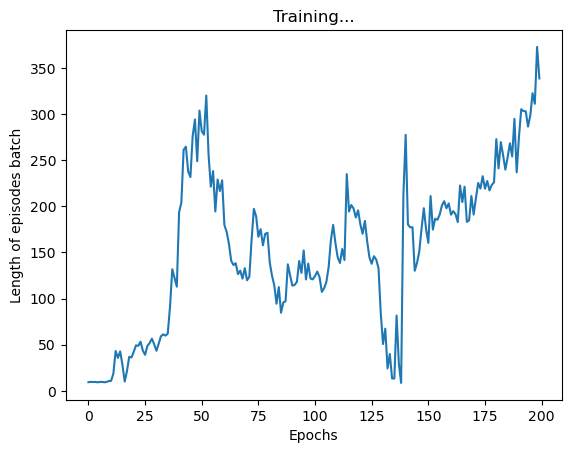

In [15]:
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 256
net_parameters['output_dim'] = 2

# instantiate network
Q_net = DQN(net_parameters)
baseline_Q_net = DQN(net_parameters).eval() 
baseline_Q_net.load_state_dict(Q_net.state_dict()) 
print(Q_net)
print(baseline_Q_net)

# instantiate memory
memory = ReplayMemory(50000) 

# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.0005 
opt_parameters['nb_episodes_per_batch'] = 1 
opt_parameters['nb_batches_per_epoch'] = 50
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['batch_size'] = 128 
opt_parameters['gamma'] = 0.999
opt_parameters['baseline_update'] = 1
init_rand_act_pr = 0.2 # starting random action prob
opt_parameters['rand_act_pr'] = init_rand_act_pr 
opt_parameters_baseline = opt_parameters.copy()
opt_parameters_baseline['nb_episodes_per_batch'] = 5
opt_parameters_baseline['rand_act_pr'] = 0.0

optimizer = torch.optim.Adam(Q_net.parameters(), lr=opt_parameters['lr'])

# select maximum episode length to learn
env = gym.make('CartPole-v1')
env._max_episode_steps = 400 # 200 400
env.spec.reward_threshold = 0.975* env._max_episode_steps
print('env._max_episode_steps',env._max_episode_steps)

# train loop
running_length = 10
all_epoch_lengths = []
batch_episode_lengths_update = 0
start = time.time()
num_epochs = 200
for epoch in range(num_epochs):
    
    # train one epoch
    epoch_train_loss, epoch_episode_length, epoch_episode_lengths = \
        train_one_epoch(env, memory, Q_net, baseline_Q_net, opt_parameters, optimizer)
    
    # update random_action_prob(=lr), linear annealing from xx% to 1%  
    opt_parameters['rand_act_pr'] = max(0.01, init_rand_act_pr - init_rand_act_pr*(epoch/float(100)))  
        
    # update baseline if current policy better (use greedy mode for evaluation)
    if not epoch%opt_parameters['baseline_update']:
        opt_parameters_baseline['env_seed'] = torch.LongTensor(opt_parameters_baseline['nb_episodes_per_batch']).random_(1,10000)
        opt_parameters_baseline['rand_act_pr'] = opt_parameters['rand_act_pr']
        batch_episode_lengths_update = rollout_batch_episodes(env, memory, opt_parameters, Q_net, False)
        batch_episode_lengths_update_baseline = rollout_batch_episodes(env, memory, opt_parameters, Q_net, False)
        if torch.Tensor(batch_episode_lengths_update).mean() > torch.Tensor(batch_episode_lengths_update_baseline).mean():
            if not (epoch+1)%10:
                print('UPDATE BASELINE - epoch:',epoch)
            baseline_Q_net.load_state_dict(Q_net.state_dict())
        else:
            if not (epoch+1)%10:
                print('NO UPDATE BASELINE - epoch:',epoch)
              
    # stop training when reward is high
    if epoch_episode_length > env.spec.reward_threshold:
        print('Training done.')
        print("Last episode length is {}, epoch is {}, random_action_prob is {}".
              format(epoch_episode_length, epoch, opt_parameters['rand_act_pr']))
        break
        
    # print intermediate info
    if not (epoch+1)%10:
        print('Epoch: {}, rand_act_pr: {:.4f}, time: {:.4f}, train_loss: {:.4f}, episode_length: {:.4f}'.format(epoch, opt_parameters['rand_act_pr'], time.time()-start, epoch_train_loss, epoch_episode_length))
        print('           memory size: {}, Qnet eval: {:.4f}, Qnet baseline eval: {:.4f}'.format(memory.__len__(), torch.Tensor(batch_episode_lengths_update).mean().item(), torch.Tensor(batch_episode_lengths_update_baseline).mean().item() ))
      
    # plot all epochs
    all_epoch_lengths.append(epoch_episode_length)
    if not (epoch+1)%10:
        if epoch<num_epochs:
            display.clear_output(wait=True)
        plt.figure(2)
        plt.title('Training...')
        plt.xlabel('Epochs')
        plt.ylabel('Length of episodes batch')
        plt.plot(torch.Tensor(all_epoch_lengths).numpy())
        plt.pause(0.01)


# Visualize

Finished at step 299


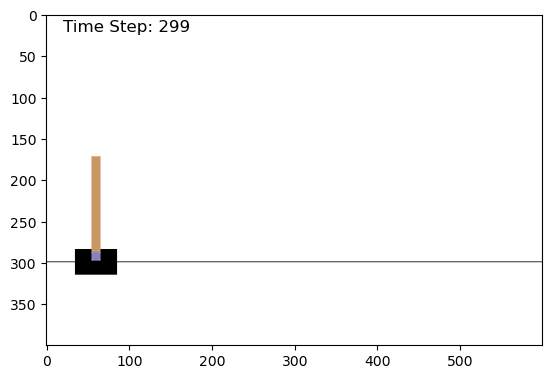

In [19]:
# For Google Colaboratory
import sys
if 'google.colab' in sys.modules:
    import gnwrapper
    env = gnwrapper.Monitor(gym.make('CartPole-v1', render_mode="rgb_array"), directory="./") 
    env._max_episode_steps = 300
    state, _ = env.reset()
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = Q_net.eval().select_action(state_pytorch, 0.0) # select action=a from state=s
        state, reward, terminated, truncated = env.step(action)
        # state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
        done = terminated or truncated
        # env.render() # no need this line with Monitor/gnwrapper; it records automatically
        if done:
            print(f"Episode finished at step {t}")
            break
    env.display()

# For Local Environment
else: 
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env._max_episode_steps = 300
    state, info = env.reset() 
    img = plt.imshow(env.render()) # Setup the plot
    time_text = plt.text(20, 20, '', color='black', fontsize=12)
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = Q_net.eval().select_action(state_pytorch, 0.0) # select action=a from state=s
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        img.set_data(env.render()) 
        time_text.set_text(f'Time Step: {t}')
        display.display(plt.gcf())
        display.clear_output(wait=True)
        if done:
            break
        env.close()
    print(f"Finished at step {t}")

        